In [1]:
pip install tensorflow 

   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 1.3/350.9 MB 3.9 MB/s eta 0:01:29
   ---------------------------------------- 2.4/350.9 MB 4.3 MB/s eta 0:01:21
   ---------------------------------------- 3.4/350.9 MB 4.5 MB/s eta 0:01:18
   ---------------------------------------- 3.9/350.9 MB 4.5 MB/s eta 0:01:17
   ---------------------------------------- 3.9/350.9 MB 4.5 MB/s eta 0:01:17
    --------------------------------------- 6.3/350.9 MB 4.5 MB/s eta 0:01:17
    --------------------------------------- 6.3/350.9 MB 4.5 MB/s eta 0:01:17
    --------------------------------------- 7.9/350.9 MB 4.3 MB/s eta 0:01:19
   - -------------------------------------- 8.9/350.9 MB 4.3 MB/s eta 0:01:20
   - -------------------------------------- 10.0/350.9 MB 4.3 MB/s eta 0:01:19
   - -------------------------------------- 10.7/350.9 MB 4.3 MB/s eta 0:01:1

In [1]:
import tensorflow as tf

In [2]:
x = tf.constant([[5,2],[1,3]])
print(x)

tf.Tensor(
[[5 2]
 [1 3]], shape=(2, 2), dtype=int32)


In [3]:
tf.random.normal(shape=(2,2),mean=0,stddev=1.)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[-0.7395009 , -0.18898483],
       [ 0.5658792 ,  0.4072645 ]], dtype=float32)>

In [4]:
init_val = tf.random.normal(shape=(2,2))
a = tf.Variable(init_val)
print(a)

<tf.Variable 'Variable:0' shape=(2, 2) dtype=float32, numpy=
array([[-0.96339995,  0.47422513],
       [ 0.43443948, -0.52780175]], dtype=float32)>


In [5]:
a = tf.random.normal(shape=(2,2))
b = tf.random.normal(shape=(2,2))
c = a + b
print(c)
d = tf.square(c)
print(d)

tf.Tensor(
[[-0.96338296 -2.381046  ]
 [ 0.7940405  -1.1610781 ]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[0.9281067 5.66938  ]
 [0.6305003 1.3481023]], shape=(2, 2), dtype=float32)


In [6]:
with tf.GradientTape 

SyntaxError: expected ':' (3351019545.py, line 1)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('FuelConsumptionCo2.csv')
data.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [7]:
x_d = data.iloc[:,4].values
y_d = data.iloc[:,12].values
#wx + b = y 

In [8]:
x = tf.constant(x_d,dtype='float32')
y = tf.constant(y_d,dtype='float32')

In [9]:
w = tf.Variable(2.0,dtype='float32')
b = tf.Variable(7.2,dtype='float32')

In [10]:
def H(x):
   y_p = w*x +b
   return y_p

In [11]:
def cost_function(y_actual,y_pred):
    mse = tf.reduce_mean(tf.square(y_actual - y_pred))
    return mse

In [13]:
lr =0.01
epochs = 1000
losses_values = []
for epoch in range(epochs):
   with tf.GradientTape() as tape:
      y_pred = H(x)
      loss = cost_function(y,y_pred)  # MSE
      losses_values.append(loss)
      gradients = tape.gradient(loss,[w,b]) # dw, db
      w.assign_sub(lr*gradients[0])   # w-= alpha*dw
      b.assign_sub(lr*gradients[1])

In [14]:
loss

<tf.Tensor: shape=(), dtype=float32, numpy=951.5821533203125>

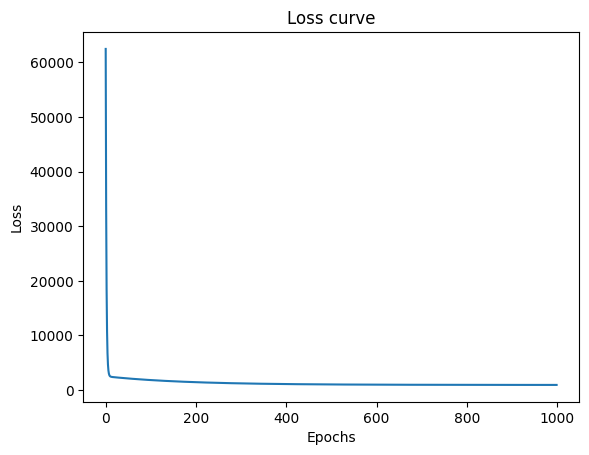

In [15]:
plt.plot(losses_values)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss curve')
plt.show()

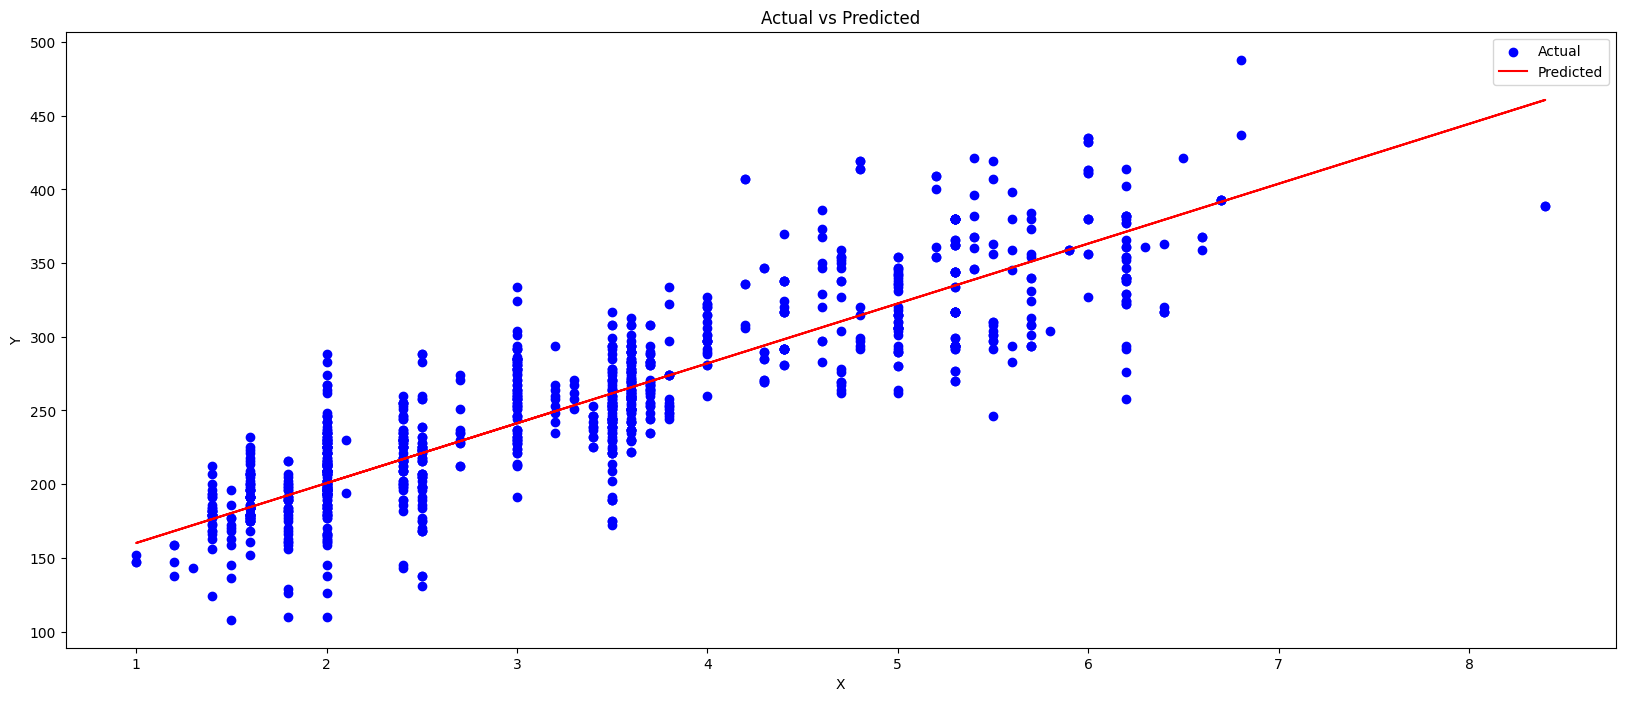

In [16]:
plt.figure(figsize=(20,8))
plt.scatter(x.numpy(),y.numpy(),color='blue',label='Actual')
plt.plot(x.numpy(),H(x).numpy(),color='red',label='Predicted')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

In [19]:
# Multilayer Perceptron
from keras.utils import plot_model
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense  # fully connected layer
visible = Input(shape=(10,))
hidden1 = Dense(500, activation='tanh')(visible)#layer-1
hidden2 = Dense(300, activation='tanh')(hidden1)
hidden3 = Dense(100, activation='tanh')(hidden2)
 
output = Dense(1, activation='sigmoid')(hidden3)
model = Model(inputs=visible, outputs=output)
# summarize layers
print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 500)            │         5,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,001 (726.57 KB)

 Trainable params: 186,001 (726.57 KB)

 Non-trainable params: 0 (0.00 B)

None
